In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import os
load_dotenv()

True

In [3]:
df = pd.read_csv("data/patient_data.csv")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head(5)

Rows: 100
Columns: 18


,patient_id,patient_name,age,gender,diagnosis,current_medication,lab_test,lab_value,lab_unit,last_visit_date,next_scheduled_visit,days_since_last_visit,missed_last_appointment,vitals_bp_systolic,vitals_bp_diastolic,vitals_heart_rate,vitals_spo2,notes
0,P0001,Aarav Sharma,68,Male,Type 2 Diabetes,Metformin 500mg,HbA1c,9.9,%,2024-04-24,2024-06-08,251,No,174,70,95,96,Patient reports good medication adherence.
1,P0002,Priya Patel,29,Male,Heart Failure,Furosemide 40mg,BNP,317.6,pg/mL,2024-01-14,2024-02-28,352,No,174,91,72,97,Patient reports no new symptoms.
2,P0003,Rohan Mehta,45,Male,"Type 2 Diabetes, CKD","Insulin Glargine 10U, Losartan 50mg",HbA1c,11.4,%,2024-08-04,2024-10-03,149,No,132,86,64,91,Medication dose adjusted this visit.
3,P0004,Anjali Singh,34,Female,"COPD, Heart Failure","Tiotropium 18mcg, Furosemide 40mg",FEV1%,33.8,%,2024-01-23,2024-04-22,343,No,153,70,93,94,Patient reports no new symptoms.
4,P0005,Vikram Nair,51,Male,"Hypertension, Heart Failure","Amlodipine 5mg, Furosemide 40mg",BP Systolic,124.9,mmHg,2024-04-26,2024-06-25,249,No,134,71,82,94,Patient education provided on diet and lifestyle.


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   patient_id               100 non-null    str    
 1   patient_name             100 non-null    str    
 2   age                      100 non-null    int64  
 3   gender                   100 non-null    str    
 4   diagnosis                100 non-null    str    
 5   current_medication       100 non-null    str    
 6   lab_test                 100 non-null    str    
 7   lab_value                100 non-null    float64
 8   lab_unit                 100 non-null    str    
 9   last_visit_date          100 non-null    str    
 10  next_scheduled_visit     100 non-null    str    
 11  days_since_last_visit    100 non-null    int64  
 12  missed_last_appointment  100 non-null    str    
 13  vitals_bp_systolic       100 non-null    int64  
 14  vitals_bp_diastolic      100 non-null 

In [5]:
df.isnull().sum()

patient_id                 0
patient_name               0
age                        0
gender                     0
diagnosis                  0
current_medication         0
lab_test                   0
lab_value                  0
lab_unit                   0
last_visit_date            0
next_scheduled_visit       0
days_since_last_visit      0
missed_last_appointment    0
vitals_bp_systolic         0
vitals_bp_diastolic        0
vitals_heart_rate          0
vitals_spo2                0
notes                      0
dtype: int64

In [6]:
df.describe()

,age,lab_value,days_since_last_visit,vitals_bp_systolic,vitals_bp_diastolic,vitals_heart_rate,vitals_spo2
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,55.360000,150.810000,211.390000,145.570000,87.680000,82.420000,94.500000
std,15.251773,279.918492,87.498675,20.375889,13.625496,14.460102,2.794294
min,28.000000,1.700000,65.000000,105.000000,65.000000,58.000000,90.000000
25%,44.000000,9.675000,132.500000,130.000000,75.750000,72.000000,92.000000
50%,55.000000,34.950000,219.000000,145.500000,87.500000,83.000000,95.000000
75%,68.000000,144.600000,287.750000,161.250000,99.250000,95.000000,97.000000
max,82.000000,1164.000000,360.000000,181.000000,110.000000,108.000000,99.000000


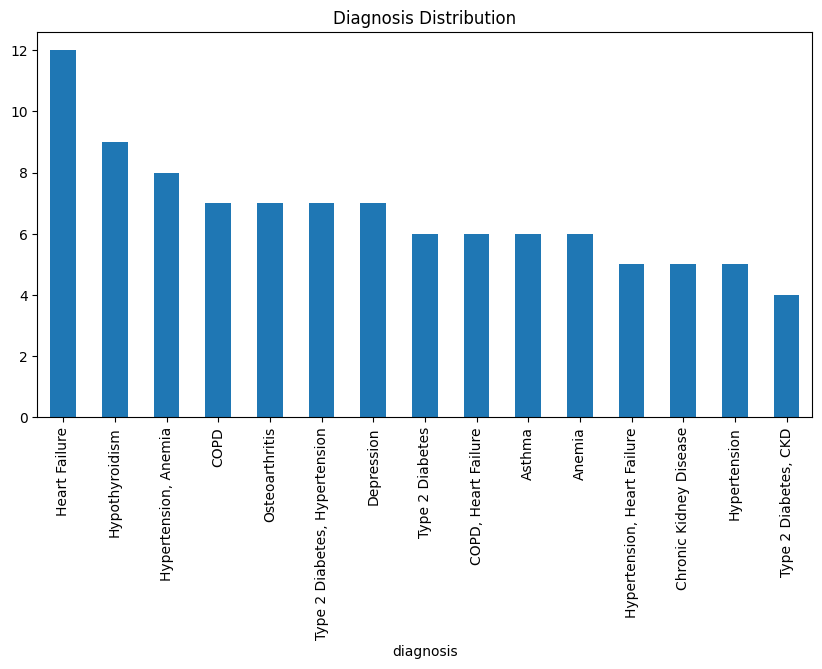

In [7]:
df["diagnosis"].value_counts().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Diagnosis Distribution")
plt.show()

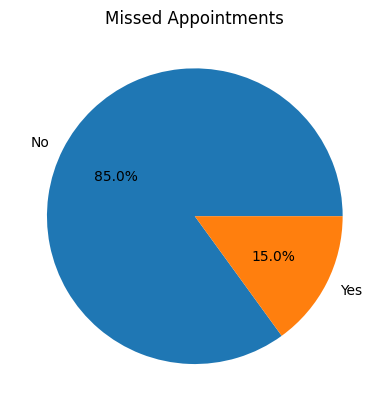

In [8]:
df["missed_last_appointment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Missed Appointments")
plt.show()

In [9]:
from src.tools import *
get_high_risk_patients(df)

,patient_id,patient_name,age,gender,diagnosis,current_medication,lab_test,lab_value,lab_unit,last_visit_date,next_scheduled_visit,days_since_last_visit,missed_last_appointment,vitals_bp_systolic,vitals_bp_diastolic,vitals_heart_rate,vitals_spo2,notes
0,P0001,Aarav Sharma,68,Male,Type 2 Diabetes,Metformin 500mg,HbA1c,9.9,%,2024-04-24,2024-06-08,251,No,174,70,95,96,Patient reports good medication adherence.
1,P0002,Priya Patel,29,Male,Heart Failure,Furosemide 40mg,BNP,317.6,pg/mL,2024-01-14,2024-02-28,352,No,174,91,72,97,Patient reports no new symptoms.
2,P0003,Rohan Mehta,45,Male,"Type 2 Diabetes, CKD","Insulin Glargine 10U, Losartan 50mg",HbA1c,11.4,%,2024-08-04,2024-10-03,149,No,132,86,64,91,Medication dose adjusted this visit.
3,P0004,Anjali Singh,34,Female,"COPD, Heart Failure","Tiotropium 18mcg, Furosemide 40mg",FEV1%,33.8,%,2024-01-23,2024-04-22,343,No,153,70,93,94,Patient reports no new symptoms.
4,P0005,Vikram Nair,51,Male,"Hypertension, Heart Failure","Amlodipine 5mg, Furosemide 40mg",BP Systolic,124.9,mmHg,2024-04-26,2024-06-25,249,No,134,71,82,94,Patient education provided on diet and lifestyle.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,P0095,Meher Patel,29,Female,"Hypertension, Anemia","Amlodipine 5mg, Ferrous Sulfate 200mg",BP Systolic,154.7,mmHg,2024-02-02,2024-05-02,333,No,143,106,84,91,Requires follow-up on lab results.
95,P0096,Sujata Acharyya,30,Male,COPD,Tiotropium 18mcg,FEV1%,74.8,%,2024-02-19,2024-04-04,316,No,122,89,87,95,Awaiting specialist report.
97,P0098,Mrinal Basu,56,Female,Heart Failure,Furosemide 40mg,BNP,1033.8,pg/mL,2024-07-07,2024-09-05,177,Yes,140,77,65,97,Patient missed doses in last week.
98,P0099,Paramita Chatterjee,70,Male,"Type 2 Diabetes, Hypertension","Metformin 500mg, Amlodipine 5mg",HbA1c,9.8,%,2024-01-26,2024-03-26,340,Yes,121,101,71,91,Awaiting specialist report.


In [11]:
sample_patient_id = df.iloc[0]["patient_id"]

patient = get_patient(
    df,
    sample_patient_id
)

print(patient)

from src.agent import run_patient_review

result = run_patient_review(patient)

print(result)

{'patient_id': 'P0001', 'patient_name': 'Aarav Sharma', 'age': 68, 'gender': 'Male', 'diagnosis': 'Type 2 Diabetes', 'current_medication': 'Metformin 500mg', 'lab_test': 'HbA1c', 'lab_value': 9.9, 'lab_unit': '%', 'last_visit_date': '2024-04-24', 'next_scheduled_visit': '2024-06-08', 'days_since_last_visit': 251, 'missed_last_appointment': 'No', 'vitals_bp_systolic': 174, 'vitals_bp_diastolic': 70, 'vitals_heart_rate': 95, 'vitals_spo2': 96, 'notes': 'Patient reports good medication adherence.'}
Analyzing patient: P0001
{'patient_id': 'P0001', 'patient_name': 'Aarav Sharma', 'analysis': '```json\n{\n  "patient_id": "P0001",\n  "risk_level": "High",\n  "clinical_concerns": [\n    "Uncontrolled blood sugar levels (HbA1c: 9.9%)",\n    "Hypertension (BP: 174/70 mmHg)",\n    "Tachycardia (Heart Rate: 95 bpm)"\n  ],\n  "recommended_actions": [\n    "Adjust medication regimen to achieve better glycemic control",\n    "Monitor and manage blood pressure",\n    "Schedule an urgent appointment fo

In [12]:
from src.agent import run_missed_appointment_agent

missed_results = run_missed_appointment_agent(df)

print(
    "Patients Reviewed:",
    len(missed_results)
)

for result in missed_results[:3]:

    print("="*80)

    print(result)


Analyzing patient: P0018
Analyzing patient: P0031
Analyzing patient: P0036
Analyzing patient: P0041
Analyzing patient: P0043
Analyzing patient: P0058
Analyzing patient: P0062
Analyzing patient: P0063
Analyzing patient: P0066
Analyzing patient: P0069
Analyzing patient: P0070
Analyzing patient: P0076
Analyzing patient: P0081
Analyzing patient: P0098
Analyzing patient: P0099
Patients Reviewed: 15
{'patient_id': 'P0018', 'patient_name': 'Lakshmi Menon', 'analysis': '```json\n{\n  "patient_id": "P0018",\n  "risk_level": "High",\n  "clinical_concerns": [\n    "Elevated BNP level (952.3 pg/mL) indicating potential worsening of heart failure",\n    "Hypertension (BP: 160/87 mmHg)",\n    "Missed last appointment, potentially indicating poor adherence to treatment plan"\n  ],\n  "recommended_actions": [\n    "Urgent follow-up appointment to reassess heart failure management",\n    "Adjustment of current medication (Furosemide 40mg) or addition of new medications to control hypertension and heart

In [ ]:
from src.agent import run_high_risk_agent

high_risk_results = run_high_risk_agent(df)

print(
    "High Risk Patients Reviewed:",
    len(high_risk_results)
)


Analyzing patient: P0001
Analyzing patient: P0002
Analyzing patient: P0003
Analyzing patient: P0004
Analyzing patient: P0005
Analyzing patient: P0006
Analyzing patient: P0008
Analyzing patient: P0010
Analyzing patient: P0011
Analyzing patient: P0012
Analyzing patient: P0013
Analyzing patient: P0014
Analyzing patient: P0015
Analyzing patient: P0016
Analyzing patient: P0017
Analyzing patient: P0018
Analyzing patient: P0019
Analyzing patient: P0020
Analyzing patient: P0021
Analyzing patient: P0022
Analyzing patient: P0024
Analyzing patient: P0027
Analyzing patient: P0028
Analyzing patient: P0029
Analyzing patient: P0030
Analyzing patient: P0031
Analyzing patient: P0032
Analyzing patient: P0033
Analyzing patient: P0034
Analyzing patient: P0036
Analyzing patient: P0037
Analyzing patient: P0038
Analyzing patient: P0039
Analyzing patient: P0040
Analyzing patient: P0041
Analyzing patient: P0043
Analyzing patient: P0044
Analyzing patient: P0046
Analyzing patient: P0047
Analyzing patient: P0048


In [ ]:
report_df = pd.DataFrame(
    missed_results
)

print(report_df.head())


report_df.to_csv(
    "./ouput/followup_report.csv",
    index=False
)

print(
    "Report Generated Successfully"
)

In [ ]:
print("Total Patients:", len(df))

print(
    "High Risk Patients:",
    len(get_high_risk_patients(df))
)

print(
    "Missed Appointments:",
    len(get_missed_appointments(df))
)